In [1]:
import pandas as pd 

In [2]:
#Using preprocessed data
dataset = pd.read_csv("flirt_dataset_v3.csv")
dataset

,Date,Time,Name,Text
0,10-04-2023,9:26 AM,Priya,The canteen menu has changed today
1,10-04-2023,9:27 AM,Priya,<Media omitted>
2,10-04-2023,9:32 AM,Priya,I love how you always make time for me
3,10-04-2023,10:13 AM,Arun,You are so cute when you smile
4,10-04-2023,10:31 AM,Priya,Missed video call
...,...,...,...,...
207,25-06-2023,19:21 PM,Priya,The traffic is really bad today
208,25-06-2023,19:44 PM,Priya,I have to submit the assignment tonight
209,25-06-2023,20:16 PM,Priya,Missed video call
210,25-06-2023,21:01 PM,Arun,The sprint ends this Friday


In [3]:
#sentimental analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
sid = SentimentIntensityAnalyzer()
senti=sid.polarity_scores(dataset['Text'][4])

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\PAVAN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [4]:
senti

{'neg': 0.524, 'neu': 0.476, 'pos': 0.0, 'compound': -0.296}

In [5]:
dataset['scores']     = dataset['Text'].apply(lambda x: sid.polarity_scores(x))
dataset['compound']   = dataset['scores'].apply(lambda x: x['compound'])
dataset['Negative']   = dataset['scores'].apply(lambda x: x['neg'])
dataset['Positive']   = dataset['scores'].apply(lambda x: x['pos'])
dataset['Neutral']    = dataset['scores'].apply(lambda x: x['neu'])
dataset['comp_score'] = dataset['compound'].apply(lambda x: 'pos' if x > 0 else 'neg')

In [6]:
dataset

,Date,Time,Name,Text,scores,compound,Negative,Positive,Neutral,comp_score
0,10-04-2023,9:26 AM,Priya,The canteen menu has changed today,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,neg
1,10-04-2023,9:27 AM,Priya,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,neg
2,10-04-2023,9:32 AM,Priya,I love how you always make time for me,"{'neg': 0.0, 'neu': 0.625, 'pos': 0.375, 'comp...",0.6369,0.000,0.375,0.625,pos
3,10-04-2023,10:13 AM,Arun,You are so cute when you smile,"{'neg': 0.0, 'neu': 0.44, 'pos': 0.56, 'compou...",0.7481,0.000,0.560,0.440,pos
4,10-04-2023,10:31 AM,Priya,Missed video call,"{'neg': 0.524, 'neu': 0.476, 'pos': 0.0, 'comp...",-0.2960,0.524,0.000,0.476,neg
...,...,...,...,...,...,...,...,...,...,...
207,25-06-2023,19:21 PM,Priya,The traffic is really bad today,"{'neg': 0.431, 'neu': 0.569, 'pos': 0.0, 'comp...",-0.5849,0.431,0.000,0.569,neg
208,25-06-2023,19:44 PM,Priya,I have to submit the assignment tonight,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,neg
209,25-06-2023,20:16 PM,Priya,Missed video call,"{'neg': 0.524, 'neu': 0.476, 'pos': 0.0, 'comp...",-0.2960,0.524,0.000,0.476,neg
210,25-06-2023,21:01 PM,Arun,The sprint ends this Friday,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,neg


In [7]:
dataset.to_csv('flirt_dataset_final.csv', index=False)

In [8]:
print(dataset['comp_score'].value_counts())

comp_score
neg    119
pos     93
Name: count, dtype: int64


In [9]:
#independent and dependent
X= dataset[['Text']]
Y= dataset['comp_score']

In [10]:
#train and test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size = 0.20,random_state=42)

In [11]:
X_train

,Text
127,<Media omitted>
108,Did you complete the homework
69,The API is returning wrong response
84,Did you watch the news today
97,I love your smile so much
...,...
106,You are so delightfully charming
14,I love how you always make me smile
92,I would love to take you out sometime
179,Can you help me with this problem


In [12]:
#Countervectorizer
from sklearn.feature_extraction.text import CountVectorizer
count_vector = CountVectorizer(stop_words = 'english')
count_train = count_vector.fit_transform(X_train['Text'])
print(count_train)
count_test = count_vector.transform(X_test['Text'])

  (0, 144)	1
  (0, 161)	1
  (1, 61)	1
  (1, 45)	1
  (1, 110)	1
  (2, 6)	1
  (2, 194)	1
  (2, 272)	1
  (2, 192)	1
  (3, 61)	1
  (3, 262)	1
  (3, 158)	1
  (3, 247)	1
  (4, 135)	1
  (4, 214)	1
  (5, 155)	1
  (5, 64)	1
  (5, 248)	1
  (6, 155)	1
  (6, 162)	1
  (6, 184)	1
  (7, 105)	1
  (7, 151)	1
  (8, 149)	1
  (8, 257)	1
  :	:
  (160, 265)	1
  (160, 44)	1
  (160, 74)	1
  (160, 193)	1
  (161, 248)	1
  (161, 189)	1
  (161, 205)	1
  (162, 155)	1
  (162, 11)	1
  (162, 250)	1
  (162, 208)	1
  (163, 155)	1
  (163, 175)	1
  (163, 176)	1
  (164, 36)	1
  (164, 57)	1
  (165, 135)	1
  (165, 214)	1
  (165, 142)	1
  (166, 135)	1
  (167, 108)	1
  (167, 178)	1
  (168, 202)	1
  (168, 172)	1
  (168, 122)	1


In [13]:
len(count_vector.get_feature_names_out())

273

In [14]:
print(count_train.toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [15]:
# model creation using Navie's bayes classification algorithm 
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics
clf_NB = MultinomialNB()
clf_NB.fit(count_train,y_train) # passing count_train from countvectorizer
#predicting using count_test from countvectorizer
pred = clf_NB.predict(count_test)
#Evaluating using accuracy,confusion matrix and classification report
score = metrics.accuracy_score(y_test, pred)
print("accuracy: %0.3f" % score)
cm = metrics.confusion_matrix(y_test,pred)
print("\nConfusion matrix:\n",cm)
from sklearn.metrics import classification_report
report=classification_report(y_test, pred)
print("\nClassification_report:\n",report)

accuracy: 0.837

Confusion matrix:
 [[26  1]
 [ 6 10]]

Classification_report:
               precision    recall  f1-score   support

         neg       0.81      0.96      0.88        27
         pos       0.91      0.62      0.74        16

    accuracy                           0.84        43
   macro avg       0.86      0.79      0.81        43
weighted avg       0.85      0.84      0.83        43



In [16]:
#model creation using PassiveAggressiveClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
clf_PAC = PassiveAggressiveClassifier()
clf_PAC.fit(count_train,y_train) # passing count_train from countvectorizer
#predicting using count_test from countvectorizer
pred = clf_PAC.predict(count_test)
#Evaluating using accuracy,confusion matrix and classification report
score = metrics.accuracy_score(y_test, pred)
print("accuracy: %0.3f" % score)
cm = metrics.confusion_matrix(y_test,pred)
print("\nConfusion matrix:\n",cm)
from sklearn.metrics import classification_report
report=classification_report(y_test, pred)
print("\nClassification_report:\n",report)

accuracy: 0.814

Confusion matrix:
 [[25  2]
 [ 6 10]]

Classification_report:
               precision    recall  f1-score   support

         neg       0.81      0.93      0.86        27
         pos       0.83      0.62      0.71        16

    accuracy                           0.81        43
   macro avg       0.82      0.78      0.79        43
weighted avg       0.82      0.81      0.81        43



C:\Users\PAVAN\anaconda3\envs\MYSpace\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


In [17]:
#model creation using Logistic regression
from sklearn.linear_model import LogisticRegression
clf_LR = LogisticRegression()
clf_LR.fit(count_train,y_train) # passing count_train from countvectorizer
#predicting using count_test from countvectorizer
pred = clf_LR.predict(count_test)
#Evaluating using accuracy,confusion matrix and classification report
score = metrics.accuracy_score(y_test, pred)
print("accuracy: %0.3f" % score)
cm = metrics.confusion_matrix(y_test,pred)
print("\nConfusion matrix:\n",cm)
from sklearn.metrics import classification_report
report=classification_report(y_test, pred)
print("\nClassification_report:\n",report)


accuracy: 0.791

Confusion matrix:
 [[26  1]
 [ 8  8]]

Classification_report:
               precision    recall  f1-score   support

         neg       0.76      0.96      0.85        27
         pos       0.89      0.50      0.64        16

    accuracy                           0.79        43
   macro avg       0.83      0.73      0.75        43
weighted avg       0.81      0.79      0.77        43



In [25]:
#model creation using SVC
from sklearn.svm import SVC
clf_SVC= SVC(kernel='rbf')
clf_SVC.fit(count_train,y_train) # passing count_train from countvectorizer
#predicting using count_test from countvectorizer
pred = clf_SVC.predict(count_test)
#Evaluating using accuracy,confusion matrix and classification report
score = metrics.accuracy_score(y_test, pred)
print("accuracy: %0.3f" % score)
cm = metrics.confusion_matrix(y_test,pred)
print("\nConfusion matrix:\n",cm)
from sklearn.metrics import classification_report
report=classification_report(y_test, pred)
print("\nClassification_report:\n",report)

accuracy: 0.837

Confusion matrix:
 [[22  5]
 [ 2 14]]

Classification_report:
               precision    recall  f1-score   support

         neg       0.92      0.81      0.86        27
         pos       0.74      0.88      0.80        16

    accuracy                           0.84        43
   macro avg       0.83      0.84      0.83        43
weighted avg       0.85      0.84      0.84        43



## As SVC accuracy(84) & f1_score is higher than other alogrithm, we are finalizing the SVC as final model

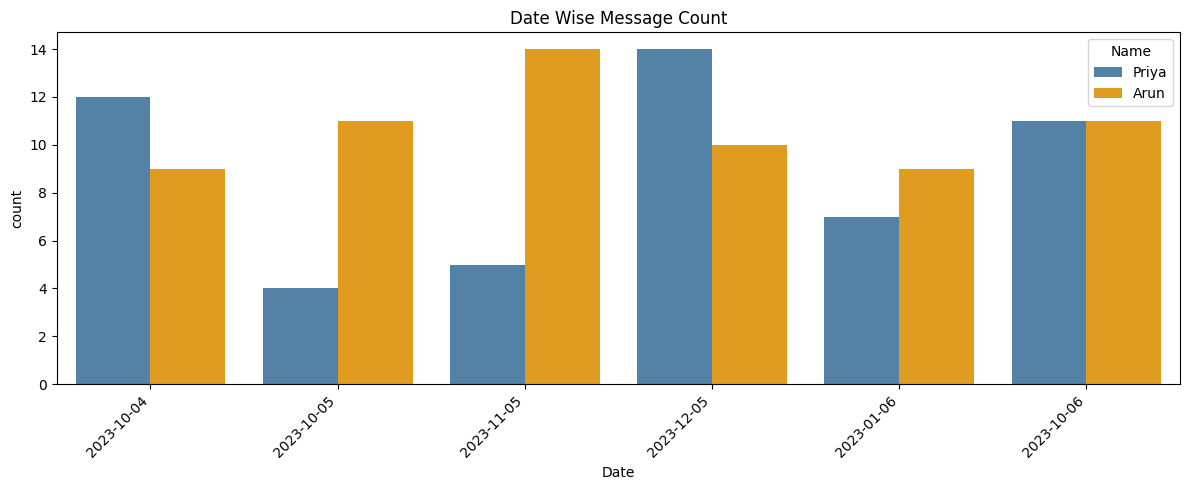

In [19]:
#Date Wise Message Count per Person 
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Date column
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')

plt.figure(figsize=(12, 5))
sns.countplot(data=dataset, x='Date', hue='Name', palette=['steelblue', 'orange'])
plt.title('Date Wise Message Count')
plt.xlabel('Date')
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Name')
plt.tight_layout()
plt.show()

## Flirt Prediction using SVC finalized model

In [20]:
# Transform full dataset text using the SAME count_vector
X_full = count_vector.transform(dataset['Text'].astype(str))

# Predict using trained clf (PAC model)
dataset['flirt_prediction'] = clf_SVC.predict(X_full)
dataset['flirt_label'] = dataset['flirt_prediction'].apply(lambda x: 'Flirty' if x == 'pos' else 'Not Flirty')
dataset[['Name', 'Text', 'comp_score', 'flirt_prediction', 'flirt_label']]

,Name,Text,comp_score,flirt_prediction,flirt_label
0,Priya,The canteen menu has changed today,neg,neg,Not Flirty
1,Priya,<Media omitted>,neg,neg,Not Flirty
2,Priya,I love how you always make time for me,pos,pos,Flirty
3,Arun,You are so cute when you smile,pos,pos,Flirty
4,Priya,Missed video call,neg,neg,Not Flirty
...,...,...,...,...,...
207,Priya,The traffic is really bad today,neg,neg,Not Flirty
208,Priya,I have to submit the assignment tonight,neg,neg,Not Flirty
209,Priya,Missed video call,neg,neg,Not Flirty
210,Arun,The sprint ends this Friday,neg,neg,Not Flirty


In [21]:
# Message count from WHATSAPP dataset
msg_count = dataset['Name'].value_counts()

# Talkative / Less Talkative
talkative      = msg_count.idxmax()
less_talkative = msg_count.idxmin()

# Flirt count from WHATSAPP dataset
flirt_counts = dataset[dataset['flirt_prediction'] == 'pos']['Name'].value_counts()

# Total messages per person from dataset
total_counts = dataset['Name'].value_counts()

# Flirt percentage
flirt_percent = (flirt_counts / total_counts * 100).round(2)

print("Flirt Encounters:")
print(f"Talkative      : {talkative}")
print(f"Less Talkative : {less_talkative}")
for name, pct in flirt_percent.items():
    print(f"Flirt Percentage by {name}: {pct}")

Flirt Encounters:
Talkative      : Priya
Less Talkative : Arun
Flirt Percentage by Arun: 49.5
Flirt Percentage by Priya: 40.54


## Time encounter 

In [22]:
# Convert Date and Time
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')
dataset['Day']  = dataset['Date'].dt.day_name()
dataset['Hour'] = pd.to_datetime(dataset['Time'].str.strip(),format='%I:%M %p', errors='coerce').dt.strftime('%I:%M %p')

# Calculations
most_active_date    = dataset['Date'].dt.date.value_counts().idxmax()
most_active_day     = dataset['Day'].value_counts().idxmax()
most_active_hour    = dataset['Hour'].value_counts().idxmax()
avg_msg_per_day     = round(dataset.groupby(dataset['Date'].dt.date).size().mean(), 1)

print("Time Encounters:")
print(f"Most Active Date              : {most_active_date}")
print(f"Most Active Day               : {most_active_day}")
print(f"Most Active Hour              : {most_active_hour}")
print(f"Average Number of Message per Day : {avg_msg_per_day}")

Time Encounters:
Most Active Date              : 2023-12-05
Most Active Day               : Friday
Most Active Hour              : 10:23 AM
Average Number of Message per Day : 19.5


## Media Encounter 

In [23]:
# Media count
media   = dataset[dataset['Text'].str.contains('<Media omitted>', na=False)]
deleted = dataset[dataset['Text'].str.contains('You deleted this message|This message was deleted', na=False)]
missed_voice = dataset[dataset['Text'].str.contains('Missed voice call', case=False, na=False)]
missed_video = dataset[dataset['Text'].str.contains('Missed video call', case=False, na=False)]

# Results
media_count       = len(media)        if len(media)        > 0 else 'No shared media'
deleted_count     = len(deleted)      if len(deleted)      > 0 else 'No message was deleted'
voice_count       = len(missed_voice) if len(missed_voice) > 0 else 'No Missed Voice Call'
video_count       = len(missed_video) if len(missed_video) > 0 else 'No Missed Video Call'

print("\nMedia Encounters:")
print(f"Media Count             : {media_count}")
print(f"Deleted Message Count   : {deleted_count}")
print(f"Missed Voice Call Count : {voice_count}")
print(f"Missed Video Call Count : {video_count}")


Media Encounters:
Media Count             : 5
Deleted Message Count   : 3
Missed Voice Call Count : 2
Missed Video Call Count : 2


## Missed call

In [27]:
# Missed Voice Call
missed_voice = dataset[dataset['Text'].str.contains('Missed voice call', case=False, na=False)]

# Missed Video Call  
missed_video = dataset[dataset['Text'].str.contains('Missed video call', case=False, na=False)]

# Results
voice_count  = len(missed_voice)  if len(missed_voice)  > 0 else 'No Missed Voice Call'
video_count  = len(missed_video)  if len(missed_video)  > 0 else 'No Missed Video Call'

print("Missed Calls:")
print(f"Missed Voice Call Count : {voice_count}")
print(f"Missed Video Call Count : {video_count}")

Missed Calls:
Missed Voice Call Count : 2
Missed Video Call Count : 2
